# Product Recommandation Engine

In [1]:
pip install surprise

  Using cached https://files.pythonhosted.org/packages/61/de/e5cba8682201fcf9c3719a6fdda95693468ed061945493dea2dd37c5618b/surprise-0.1-py2.py3-none-any.whl
  Using cached https://files.pythonhosted.org/packages/97/37/5d334adaf5ddd65da99fc65f6507e0e4599d092ba048f4302fe8775619e8/scikit-surprise-1.1.1.tar.gz
  Complete output from command C:\Users\Ganesan\Anaconda3\python.exe -u -c "import setuptools, tokenize;__file__='C:\\Users\\Ganesan\\AppData\\Local\\Temp\\pip-install-1xj57ybm\\scikit-surprise\\setup.py';f=getattr(tokenize, 'open', open)(__file__);code=f.read().replace('\r\n', '\n');f.close();exec(compile(code, __file__, 'exec'))" bdist_wheel -d C:\Users\Ganesan\AppData\Local\Temp\pip-wheel-samx3f9a --python-tag cp37:
  running bdist_wheel
  running build
  running build_py
  creating build
  creating build\lib.win-amd64-3.7
  creating build\lib.win-amd64-3.7\surprise
  copying surprise\accuracy.py -> build\lib.win-amd64-3.7\surprise
  copying surprise\builtin_datasets.py -> build\li

  Failed building wheel for scikit-surprise
Command "C:\Users\Ganesan\Anaconda3\python.exe -u -c "import setuptools, tokenize;__file__='C:\\Users\\Ganesan\\AppData\\Local\\Temp\\pip-install-1xj57ybm\\scikit-surprise\\setup.py';f=getattr(tokenize, 'open', open)(__file__);code=f.read().replace('\r\n', '\n');f.close();exec(compile(code, __file__, 'exec'))" install --record C:\Users\Ganesan\AppData\Local\Temp\pip-record-r7ndjqyt\install-record.txt --single-version-externally-managed --compile" failed with error code 1 in C:\Users\Ganesan\AppData\Local\Temp\pip-install-1xj57ybm\scikit-surprise\


In [3]:
import surprise

ModuleNotFoundError: No module named 'surprise'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as px
sns.set(style="darkgrid")
sns.set(color_codes=True)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [41]:
#To display comments/observations in 'orange' color and bold
def b(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Observations:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def c(text):
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def f(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Final Comments:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")

## 1. Read and explore the given dataset. ( Rename column/add headers, plot histograms, find data characteristics)

In [55]:
df_org = pd.read_csv('ratings_Electronics.csv', header=None)

In [56]:
df_org.head()

,0,1,2,3
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [57]:
df_org.columns = ['user_id', 'product_id', 'ratings', 'timestamp']

In [58]:
df_org.head()

,user_id,product_id,ratings,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [59]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
user_id       object
product_id    object
ratings       float64
timestamp     int64
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


In [60]:
#Row and column size in the dataset
df_org.shape

(7824482, 4)

In [61]:
#dropping timestamp column
df_org.drop(['timestamp'], axis=1, inplace=True)

In [65]:
df_org.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
ratings,7824482.0,4.012337,1.38091,1.0,3.0,5.0,5.0,5.0


In [68]:
print("Does dataframe contains any null values? ",df_org.isnull().values.any()) # dataframe contains only 'false' which means there are no null values.
total_nan = df_org.isnull().sum().sum()
if total_nan > 0:
    b("==> There are NaN values present in the original dataset. Null count is", total_nan)
else:
    b("==> There are no NaN values present in the original dataset")

Does dataframe contains any null values?  False
 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are no NaN values present in the original dataset 


 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are no outliers in the columns as it contains values ranges between 1 and 5 


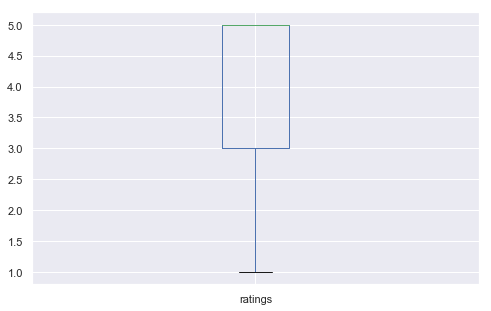

In [99]:
#Finding outliers & handling them
plt.figure(figsize=(8,5))
df_org.boxplot(column=['ratings'])
b("==> There are no outliers in the columns as it contains values ranges between 1 and 5")

In [72]:
df_org.nunique()

user_id       4201696
product_id     476002
ratings             5
dtype: int64

ratings
1.0     901765
2.0     456322
3.0     633073
4.0    1485781
5.0    4347541
Name: ratings, dtype: int64

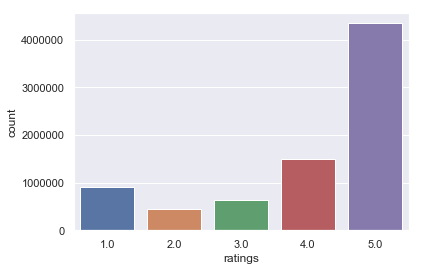

In [84]:
sns.countplot(df_org['ratings']);
df_org.groupby(['ratings'])['ratings'].count()

In [81]:
b("==> Columns 'user_id' and 'product_id' are displayed as df object as they are considered as unique identifiers. Column 'ratings' is considered as float.\n==> There are no null or empty values in dataframe.\n==>I'm dropping column 'timestamp' as it is not much useful for builindg recommandation engine.\n==>The column 'rating' ranges between 1 and 5. There are enormous records with rating 5 than other ratings.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Columns 'user_id' and 'product_id' are displayed as df object as they are considered as unique identifiers. Column 'ratings' is considered as float.
==> There are no null or empty values in dataframe.
==>I'm dropping column 'timestamp' as it is not much useful for builindg recommandation engine.
==>The column 'rating' ranges between 1 and 5. There are enormous records with rating 5 than other ratings. 


## 2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )

In [85]:
df_org.groupby(['ratings']).count()

,user_id,product_id
ratings,,
1.0,901765,901765
2.0,456322,456322
3.0,633073,633073
4.0,1485781,1485781
5.0,4347541,4347541


In [100]:
#finding users that have given 50 or more ratings

usr_grp = df_org.groupby("user_id")
usr_rat_cnt_df = usr_grp[['ratings']].count().reset_index()
usr_rat_cnt_df_50 = usr_rat_cnt_df[usr_rat_cnt_df['ratings']>=50]
usr_rat_cnt_df_50.columns = ['user_id','user_ratings_cnt']

In [101]:
usr_rat_cnt_df_50.head()

,user_id,user_ratings_cnt
5506,A100UD67AHFODS,116
5558,A100WO06OQR8BQ,132
9928,A105S56ODHGJEK,68
9965,A105TOJ6LTVMBG,71
13836,A10AFVU66A79Y1,65


In [103]:
#filtering users that have given 50 ore more ratings from orginal dataset
usr_50_df = pd.merge(df_org,usr_rat_cnt_df_50,on=['user_id'],how='inner')[['user_id','product_id','ratings','user_ratings_cnt']]

In [104]:
usr_50_df.head()

,user_id,product_id,ratings,user_ratings_cnt
0,A3BY5KCNQZXV5U,0594451647,5.0,50
1,A3BY5KCNQZXV5U,B00000JD4V,4.0,50
2,A3BY5KCNQZXV5U,B000063574,5.0,50
3,A3BY5KCNQZXV5U,B0000CDJP8,5.0,50
4,A3BY5KCNQZXV5U,B0007Y794O,5.0,50


ratings
1.0     5115
2.0     5367
3.0    12060
4.0    32295
5.0    71034
Name: ratings, dtype: int64

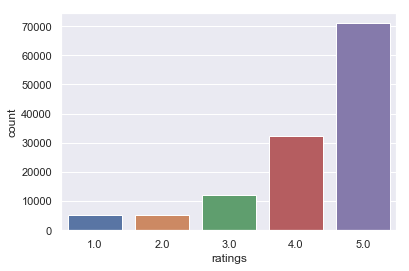

In [106]:
sns.countplot(usr_50_df['ratings']);
usr_50_df.groupby(['ratings'])['ratings'].count()

In [122]:
usr_50_df[usr_50_df['user_ratings_cnt']>200].head()

,user_id,product_id,ratings,user_ratings_cnt
1479,A5JLAU2ARJ0BO,1400532655,1.0,520
1480,A5JLAU2ARJ0BO,B00003006R,5.0,520
1481,A5JLAU2ARJ0BO,B00003G1RG,3.0,520
1482,A5JLAU2ARJ0BO,B00004S9AK,5.0,520
1483,A5JLAU2ARJ0BO,B00004SB92,4.0,520


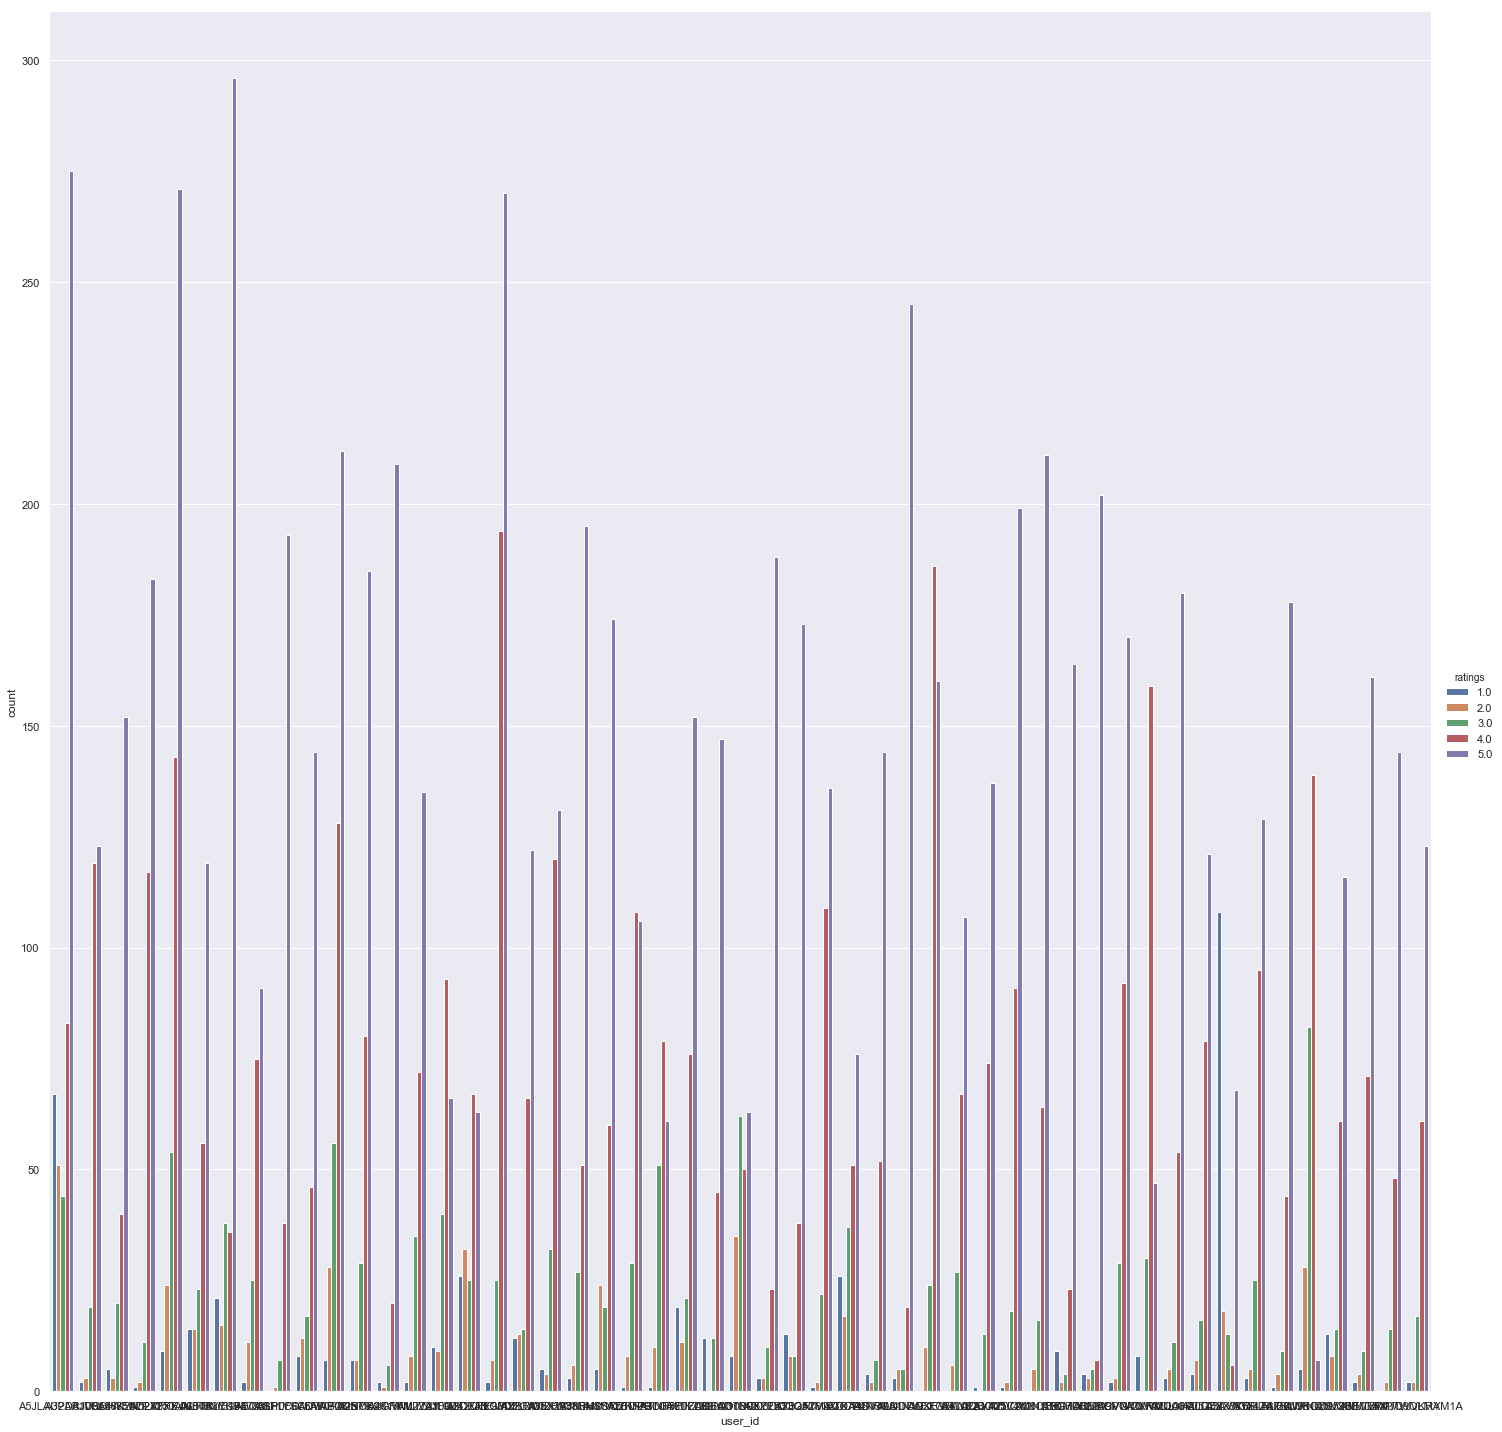

In [135]:
# userid and its rating count(includes rating between 1 and 5). Below plot shows only the users that have given more than 200 ratings.
sns.catplot(x='user_id',hue='ratings',data=usr_50_df[usr_50_df['user_ratings_cnt']>200], kind='count',height=20);

In [134]:
b("==> The above bar plot shows the count of rating based records after considering only the users that have given ratings 50 or more times. Based on which, it's clear that approx. 60% records are with rating 5.\n==> From the above sample data(rating count >200) showed in catplot, most of the users have given either rating 5 or 4 predominantly.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> The above bar plot shows the count of rating based records after considering only the users that have given ratings 50 or more times. Based on which, it's clear that approx. 60% records are with rating 5.
==> From the above sample data(rating count >200) showed in catplot, most of the users have given either rating 5 or 4 predominantly. 


In [137]:
# taking products that have 5000 or more ratings
prd_grp = df_org.groupby('product_id')
prd_rat_cnt_df = prd_grp[['ratings']].count().reset_index()
prd_rat_cnt_df_50 = prd_rat_cnt_df[prd_rat_cnt_df['ratings']>=5000]
prd_rat_cnt_df_50.columns = ['product_id','product_ratings_cnt']

In [138]:
b("==> The PRODUCTS which has 5000 or more ratings has been picked to pick more popular products from prominent users")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> The PRODUCTS which has 5000 or more ratings has been picked to pick more popular products from prominent users 


In [140]:
#Joining user rating count and product rating count dataframes
usr_prd_50_df = pd.merge(usr_50_df,prd_rat_cnt_df_50,on=['product_id'],how='inner')[['user_id','product_id','ratings','user_ratings_cnt','product_ratings_cnt']]
usr_prd_50_df.head(20)

,user_id,product_id,ratings,user_ratings_cnt,product_ratings_cnt
0,A3BY5KCNQZXV5U,B009A5204K,4.0,50,7059
1,A32HSNCNPRUMTR,B009A5204K,4.0,72,7059
2,A3OZA8HNJM26DC,B009A5204K,5.0,54,7059
3,A2PK64OVZA1U8Z,B009A5204K,4.0,82,7059
4,A21NS06GDEA3V0,B009A5204K,5.0,59,7059
5,A37IRE9GZ0CZ7I,B009A5204K,5.0,97,7059
6,A18OTCHQ6MXD6X,B009A5204K,5.0,73,7059
7,AETQIN7OH0RL9,B009A5204K,3.0,54,7059
8,A1NQFT941TOTT7,B009A5204K,2.0,56,7059
9,A3BY5KCNQZXV5U,B00BGGDVOO,4.0,50,6893


## 3. Build Popularity Recommender model.

In [146]:
#Top 10 products based on Product highest average rating
popular_df = usr_prd_50_df.groupby('product_id')
b("==> Building the popularity based data based on USERS with 25 or more ratings and PRODUCTS with 5000 or more ratings.\n==> Top PRODUCTS in terms of COUNT of RATINGS")
pd.DataFrame(popular_df['ratings'].mean().sort_values(ascending=False).head(10))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Building the popularity based data based on USERS with 25 or more ratings and PRODUCTS with 5000 or more ratings.
==> Top PRODUCTS in terms of COUNT of RATINGS 


,ratings
product_id,
B00316263Y,4.868421
B003ES5ZUU,4.864130
B0019EHU8G,4.855556
B002WE6D44,4.770000
B007R5YDYA,4.769231
B007WTAJTO,4.701220
B0098F5W0Q,4.666667
B003LR7ME6,4.647059
B0002L5R78,4.611940


In [2]:
#Top 10 products based on Product rating count based
pd.DataFrame(popular_df['product_ratings_cnt'].mean().sort_values(ascending=False).head(10))

NameError: name 'pd' is not defined

In [4]:
from surprise.model_selection import train_test_split
from surprise import Dataset
from surprise import Reader
from surprise import KNNWithMeans, accuracy
from surprise import SVD

ModuleNotFoundError: No module named 'surprise'

## 4. Split the data randomly into a train and test dataset. ( For example, split it in 70/30 ratio)

## 5. Build Collaborative Filtering model.

## 6. Evaluate the above model. ( Once the model is trained on the training data, it can be used to compute the error (like RMSE) on redictions made on the test data.) You can also use a different method to evaluate the models.

## 7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.

## 8. Summarise your insights.